# Bank Balance Sheet Risk Replication (Jiang et al. 2024)

This notebook provides a walkthrough of the replication pipeline used in this project.

The workflow:

1. Pull FFIEC data directly
2. Process FFIEC data and make table 1A and figure 1A
3. Load the cleaned FFIEC bank panel
4. Inspect balance sheet exposures
5. Load market shocks from Treasury and MBS markets
6. Review simulated losses
7. Display the generated Table 1

All data are produced by the automated pipeline using `doit`.

## Overview

This notebook explores the cleaned data produced by the automated `doit` pipeline.
Before running this notebook, ensure the pipeline has been run:
```bash
doit
```

The pipeline downloads FFIEC Call Report data, processes it into a bank panel,
computes market shocks, and generates Table 1.

In [1]:
from pathlib import Path
import pandas as pd
import plotly.express as px

from settings import config

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))
REPORT_DATE = config("REPORT_DATE")

print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)

Data directory: C:\Users\hashi\OneDrive - Higher Education Commission\Desktop\Uchicago Classes\Quarter 5\Fullstack quant\p08_jiang_et_al_2024\_data
Output directory: C:\Users\hashi\OneDrive - Higher Education Commission\Desktop\Uchicago Classes\Quarter 5\Fullstack quant\p08_jiang_et_al_2024\_output


## Bank Panel

The bank panel is built from FFIEC Call Report schedules and contains one row per bank.
It includes:

- **Total Asset / Uninsured Deposit** — balance sheet size and deposit fragility
- **rmbs_lt1y, rmbs_1_3y ...** — RMBS holdings broken into maturity buckets
- **treasury_lt1y, treasury_1_3y ...** — Treasury holdings by maturity
- **res_mtg_lt1y ...** — Residential mortgage loans by maturity
- **other_loan_lt1y ...** — Other loans by maturity

These maturity buckets are the key inputs for computing mark-to-market losses
when interest rates rise.

In [21]:
bank_panel = pd.read_parquet(DATA_DIR / f"bank_panel_{REPORT_DATE}.parquet")

print("Shape:", bank_panel.shape)

bank_panel.head()

Shape: (4394, 66)


,rssd_id_call,Total Asset,cash,security_total,security_treasury,security_rmbs,security_cmbs,security_abs,security_other,Total_Loan,...,Uninsured Short-Term Time Deposits,Foreign Deposit,Fed Fund Purchase,Repo,Other Liability,Total Equity,Common Stock,Preferred Stock,Retained Earning,report_date
0,37,86116.0,17422.0,47217.0,0.0,0.0,0.0,0.0,0.0,19485.0,...,864,NaN,0,0.0,127.0,13639.0,1200.0,0.0,12897.0,12312025
1,242,56044.0,3138.0,18513.0,3118.0,0.0,0.0,0.0,0.0,30386.0,...,4039,NaN,0,0.0,84.0,5282.0,120.0,0.0,6106.0,12312025
2,279,428509.0,9370.0,76636.0,0.0,0.0,0.0,0.0,0.0,306644.0,...,31940,NaN,0,0.0,2560.0,48665.0,1.0,0.0,34475.0,12312025
3,354,123554.0,4170.0,2128.0,501.0,0.0,0.0,0.0,0.0,98393.0,...,3069,NaN,0,0.0,922.0,12729.0,100.0,0.0,-1492.0,12312025
4,457,87633.0,5864.0,493.0,493.0,0.0,0.0,0.0,0.0,79786.0,...,6029,NaN,0,0.0,278.0,8097.0,60.0,0.0,3107.0,12312025


## Bank Size Categories

Banks are classified into three groups based on total assets:

- **Small** — below $1.384B
- **Large (non-GSIB)** — above $1.384B but not a GSIB
- **GSIB** — Global Systemically Important Banks (e.g. JPMorgan, BofA, Citi)

In [22]:
threshold = 1.384e6  # in thousands

small = (bank_panel["Total Asset"] < threshold).sum()
large_non_gsib = (bank_panel["Total Asset"] >= threshold).sum()

print(f"Total banks:      {len(bank_panel)}")
print(f"Small banks:      {small}")
print(f"Large non-GSIB:   {large_non_gsib}")

Total banks:      4394
Small banks:      3585
Large non-GSIB:   809


## Bank Asset Distribution

The vast majority of U.S. banks are small community banks with under $1B in assets.
A handful of mega-banks (GSIBs) hold a disproportionate share of total assets.
We use a log scale to show the full distribution clearly.

In [23]:
import numpy as np

fig = px.histogram(
    bank_panel,
    x=np.log10(bank_panel["Total Asset"].replace(0, np.nan)),
    nbins=100,
    title="Distribution of Bank Assets (Log Scale)",
    labels={"x": "Total Assets"},
)

fig.update_xaxes(
    tickvals=[3, 4, 5, 6, 7, 8, 9],
    ticktext=["$1M", "$10M", "$100M", "$1B", "$10B", "$100B", "$1T"]
)

# Add threshold line
fig.add_vline(
    x=np.log10(1.384e6),
    line_dash="dash",
    line_color="red",
    annotation_text="$1.384B threshold",
)

fig

## Uninsured Deposits

Uninsured deposits (above the FDIC $250K insurance limit) are a key measure of 
bank fragility in Jiang et al. Banks with high uninsured deposits are more vulnerable 
to runs when they have large unrealized losses — depositors have more incentive to 
withdraw since their funds are not protected.

In [17]:
fig = px.histogram(
    bank_panel,
    x=np.log10(bank_panel["Uninsured Deposit"].replace(0, np.nan)),
    nbins=100,
    title="Distribution of Uninsured Deposits (Log Scale)",
    labels={"x": "Log10(Uninsured Deposit)"},
)

fig.update_xaxes(
    tickvals=[3, 4, 5, 6, 7, 8, 9],
    ticktext=["$1M", "$10M", "$100M", "$1B", "$10B", "$100B", "$1T"]
)

fig

c:\Users\hashi\miniforge3\envs\finm\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log10



In [24]:
bank_panel["uninsured_ratio"] = (
    bank_panel["Uninsured Deposit"] / bank_panel["Total Asset"] * 100
)

fig = px.histogram(
    bank_panel,
    x="uninsured_ratio",
    nbins=100,
    title="Uninsured Deposits as % of Total Assets",
    labels={"uninsured_ratio": "Uninsured Deposit / Total Asset (%)"},
)

fig

## Balance Sheet Composition (Figure A1)

The chart below shows the aggregate U.S. banking system balance sheet composition.
On the asset side, the major categories are cash, securities, real estate loans, and other loans.
On the liability side, the key distinction is between insured and uninsured deposits —
uninsured deposits are the primary source of run risk in Jiang et al.

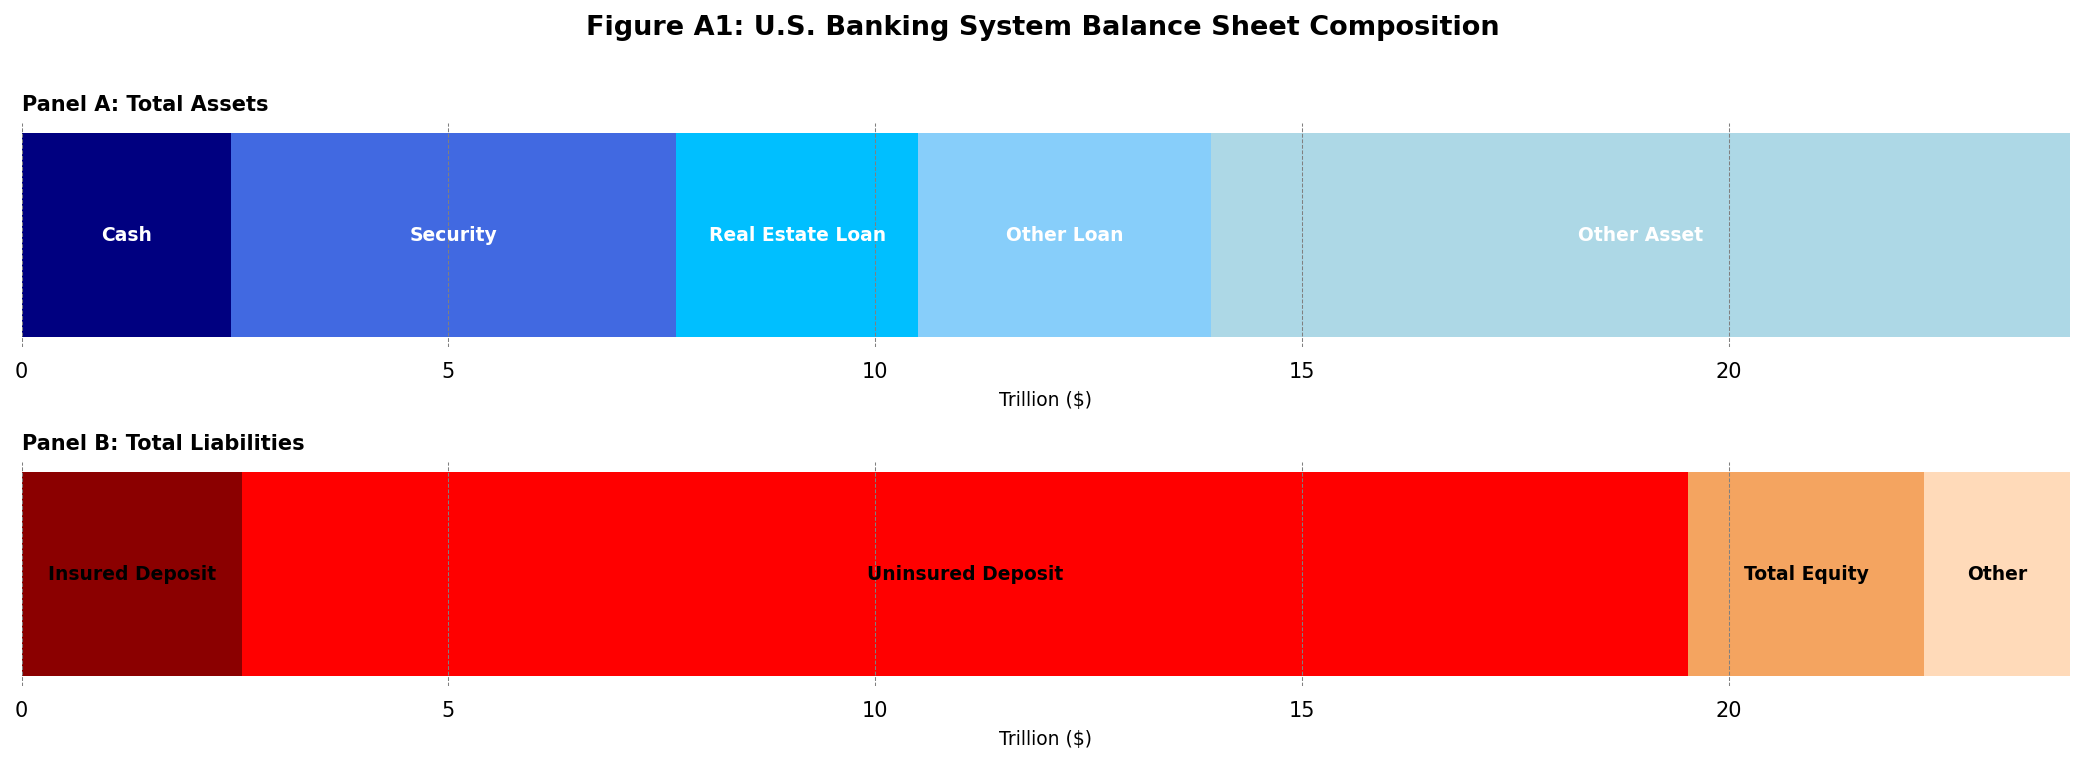

In [25]:
from IPython.display import Image
Image(str(OUTPUT_DIR / f"figure_A1_{REPORT_DATE}.png"))

## Maturity Bucket Exposures

To compute mark-to-market losses, each bank's securities and loan holdings are broken into maturity buckets: lt1y, 1_3y, 3_5y, 5_10y, 10_15y, 15plus.

Note that RMBS holdings have actual maturity data from FFIEC. However, Treasury, residential mortgage, and other loan buckets are allocated using fixed assumed weights since FFIEC does not report maturity breakdowns for these categories.

In [27]:
prefixes = ["rmbs_", "treasury_", "res_mtg_", "other_loan_"]

rows = []
for prefix in prefixes:
    cols = [c for c in bank_panel.columns if c.startswith(prefix)]
    rows.append({
        "Asset Class": prefix.replace("_", " ").title().strip(),
        **{c.replace(prefix, ""): round(bank_panel[c].sum() * 1000 / 1e9, 1) for c in cols}
    })

bucket_summary = pd.DataFrame(rows).set_index("Asset Class")
bucket_summary.columns.name = "Maturity Bucket"

# Add a total column
bucket_summary["Total"] = bucket_summary.sum(axis=1)

bucket_summary.style.format("${:,.1f}B")

Maturity Bucket,lt1y,1_3y,3_5y,5_10y,10_15y,15plus,Total
Asset Class,,,,,,,
Rmbs,$471.6B,"$1,072.9B",$1.2B,$332.3B,$0.0B,$23.8B,"$1,901.8B"
Treasury,$290.7B,$363.4B,$290.7B,$290.7B,$145.3B,$72.7B,"$1,453.5B"
Res Mtg,$110.1B,$220.2B,$330.3B,$550.5B,$550.5B,$440.4B,"$2,202.0B"
Other Loan,$863.9B,$863.9B,$863.9B,$863.9B,$432.0B,$432.0B,"$4,319.6B"


## Load market shocks

Market shocks are estimated from Treasury yield changes and MBS ETF price movements.

In [20]:
shocks = pd.read_parquet(DATA_DIR / "market_shocks.parquet")

shocks

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hashi\\OneDrive - Higher Education Commission\\Desktop\\Uchicago Classes\\Quarter 5\\Fullstack quant\\p08_jiang_et_al_2024\\_data\\market_shocks.parquet'

## Inspect shock magnitudes

In [ ]:
shock_cols = [c for c in shocks.columns if c.startswith("d_tsy_")]

fig = px.bar(
    x=shock_cols,
    y=shocks.loc[0, shock_cols],
    title="Treasury Yield Shock by Maturity",
)

fig

## Load Table 1 results

Table 1 summarizes simulated mark-to-market losses by bank size group.

In [ ]:
table1 = pd.read_csv(OUTPUT_DIR / "table_1.csv", index_col=0)

table1

## Summary

This notebook demonstrates the key outputs of the replication pipeline:

* Cleaned FFIEC bank panel
* Estimated market shocks
* Mark-to-market loss calculations
* Table 1 summary statistics

The full pipeline is automated using `doit` to ensure reproducibility.